# *Analising viability of VLMs in Missing Items/Ingredients problem (Order Accuracy & Item Verification)*

### *Initial Considerations*:

*We consider the following problem domain*:

- ***Business Line*** :  *Food*
- ***Main Category*** : *Order Accuracy & Item Verification*
- ***Specific Problem*** : *Missing Items/Ingredients*
- ***Problem Description*** : *Claims that specific extras (e.g., extra bacon, side sauce, specific drink) were omitted*
- ***Potential AI solution*** : Object detection models trained on menu items to count components in an open box or bag

### *Proposed Pipeline*:

*To test whether a Vision-Language Model (VLM) can identify omitted ingredients or missing order items without relying on rare, manually labeled fraud datasets, we implement an synthetic data generation and evaluation framework based on the following suggested steps:*


- ***Step 1 - Dataset acquisition & Ground Truth inspection (UNIFEI / Mendeley Data)*** : Download the Brazilian Food Images Dataset (CC BY 4.0), which provides multi-item meal images (Pratos Feitos) along with paired ground-truth segmentation masks for specific ingredients (e.g., milanese steak, fries, salad).

- ***Step 2 - Object segmentation & Mask generation (SAM)*** : Employ the Segment Anything Model (SAM) to generate precise binary masks isolating targeted items (e.g., side sauces, canned drinks, or side portions) slated for removal. Benchmark the predicted masks against the dataset's Ground Truth masks to evaluate segmentation accuracy before image manipulation.

- ***Step 3.1 - Synthetic omission via Pixel Zeroing (Blackout)*** : Process the original images using box-prompted Segment Anything Model (SAM) masks, expanded via morphological dilation to capture edge artifacts, applying a deterministic Pixel Zeroing technique ([0, 0, 0]) over the dilated mask region to completely remove the targeted food item. This guarantees a clean, artifact-free missing item visual, eliminating generative hallucinations (e.g., duplicate food items) and providing an unbiased input for the VLM order cross-verification.

- ***(Alternatively to step 3.1) Step 3.2 - Synthetic Omission via Inpainting (Stable Diffusion)*** : Feed the original images and generated masks into an Inpainting Pipeline (e.g., Stable Diffusion Inpainting). The model removes the selected item and seamlessly reconstructs the background, synthesizing realistic "incomplete order" claims.

- ***Step 4 - Semantic Cross-Verification (Qwen-VL Inference)*** : Pass both the original and inpainted images to Qwen-VL alongside a cross-referencing prompt containing the expected receipt items (e.g., "Cross-check the image against the order receipt: [Main, Side, Drink]. Report any missing items.").


# ***Step 1 - Dataset acquisition & Ground Truth inspection (UNIFEI / Mendeley Data)***

*In this step, we download the Brazilian Food Images Dataset provided by researchers at the Federal University of Itajubá (UNIFEI) via Mendeley Data. This dataset contains 20 classes of traditional Brazilian meals (Pratos Feitos), pairing complete meal images with ground-truth segmentation masks for specific ingredients (e.g., milanese steak, fries, beans, rice)*.

- ***Dataset Source*** : Mendeley Data (CC BY 4.0 License)
- ***Citation*** : de Carvalho, Marcos Alberto (2023), “Brazilian food images”, Mendeley Data, V2, doi: 10.17632/7n36jtcpv3.2
- ***License*** : [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)
- ***Modifications Note*** : Images from this dataset were modified strictly for academic research purposes via Generative Inpainting (Stable Diffusion) to generate synthetic missing item samples
- ***More information*** : https://data.mendeley.com/datasets/7n36jtcpv3/2

Mounted at /content/drive


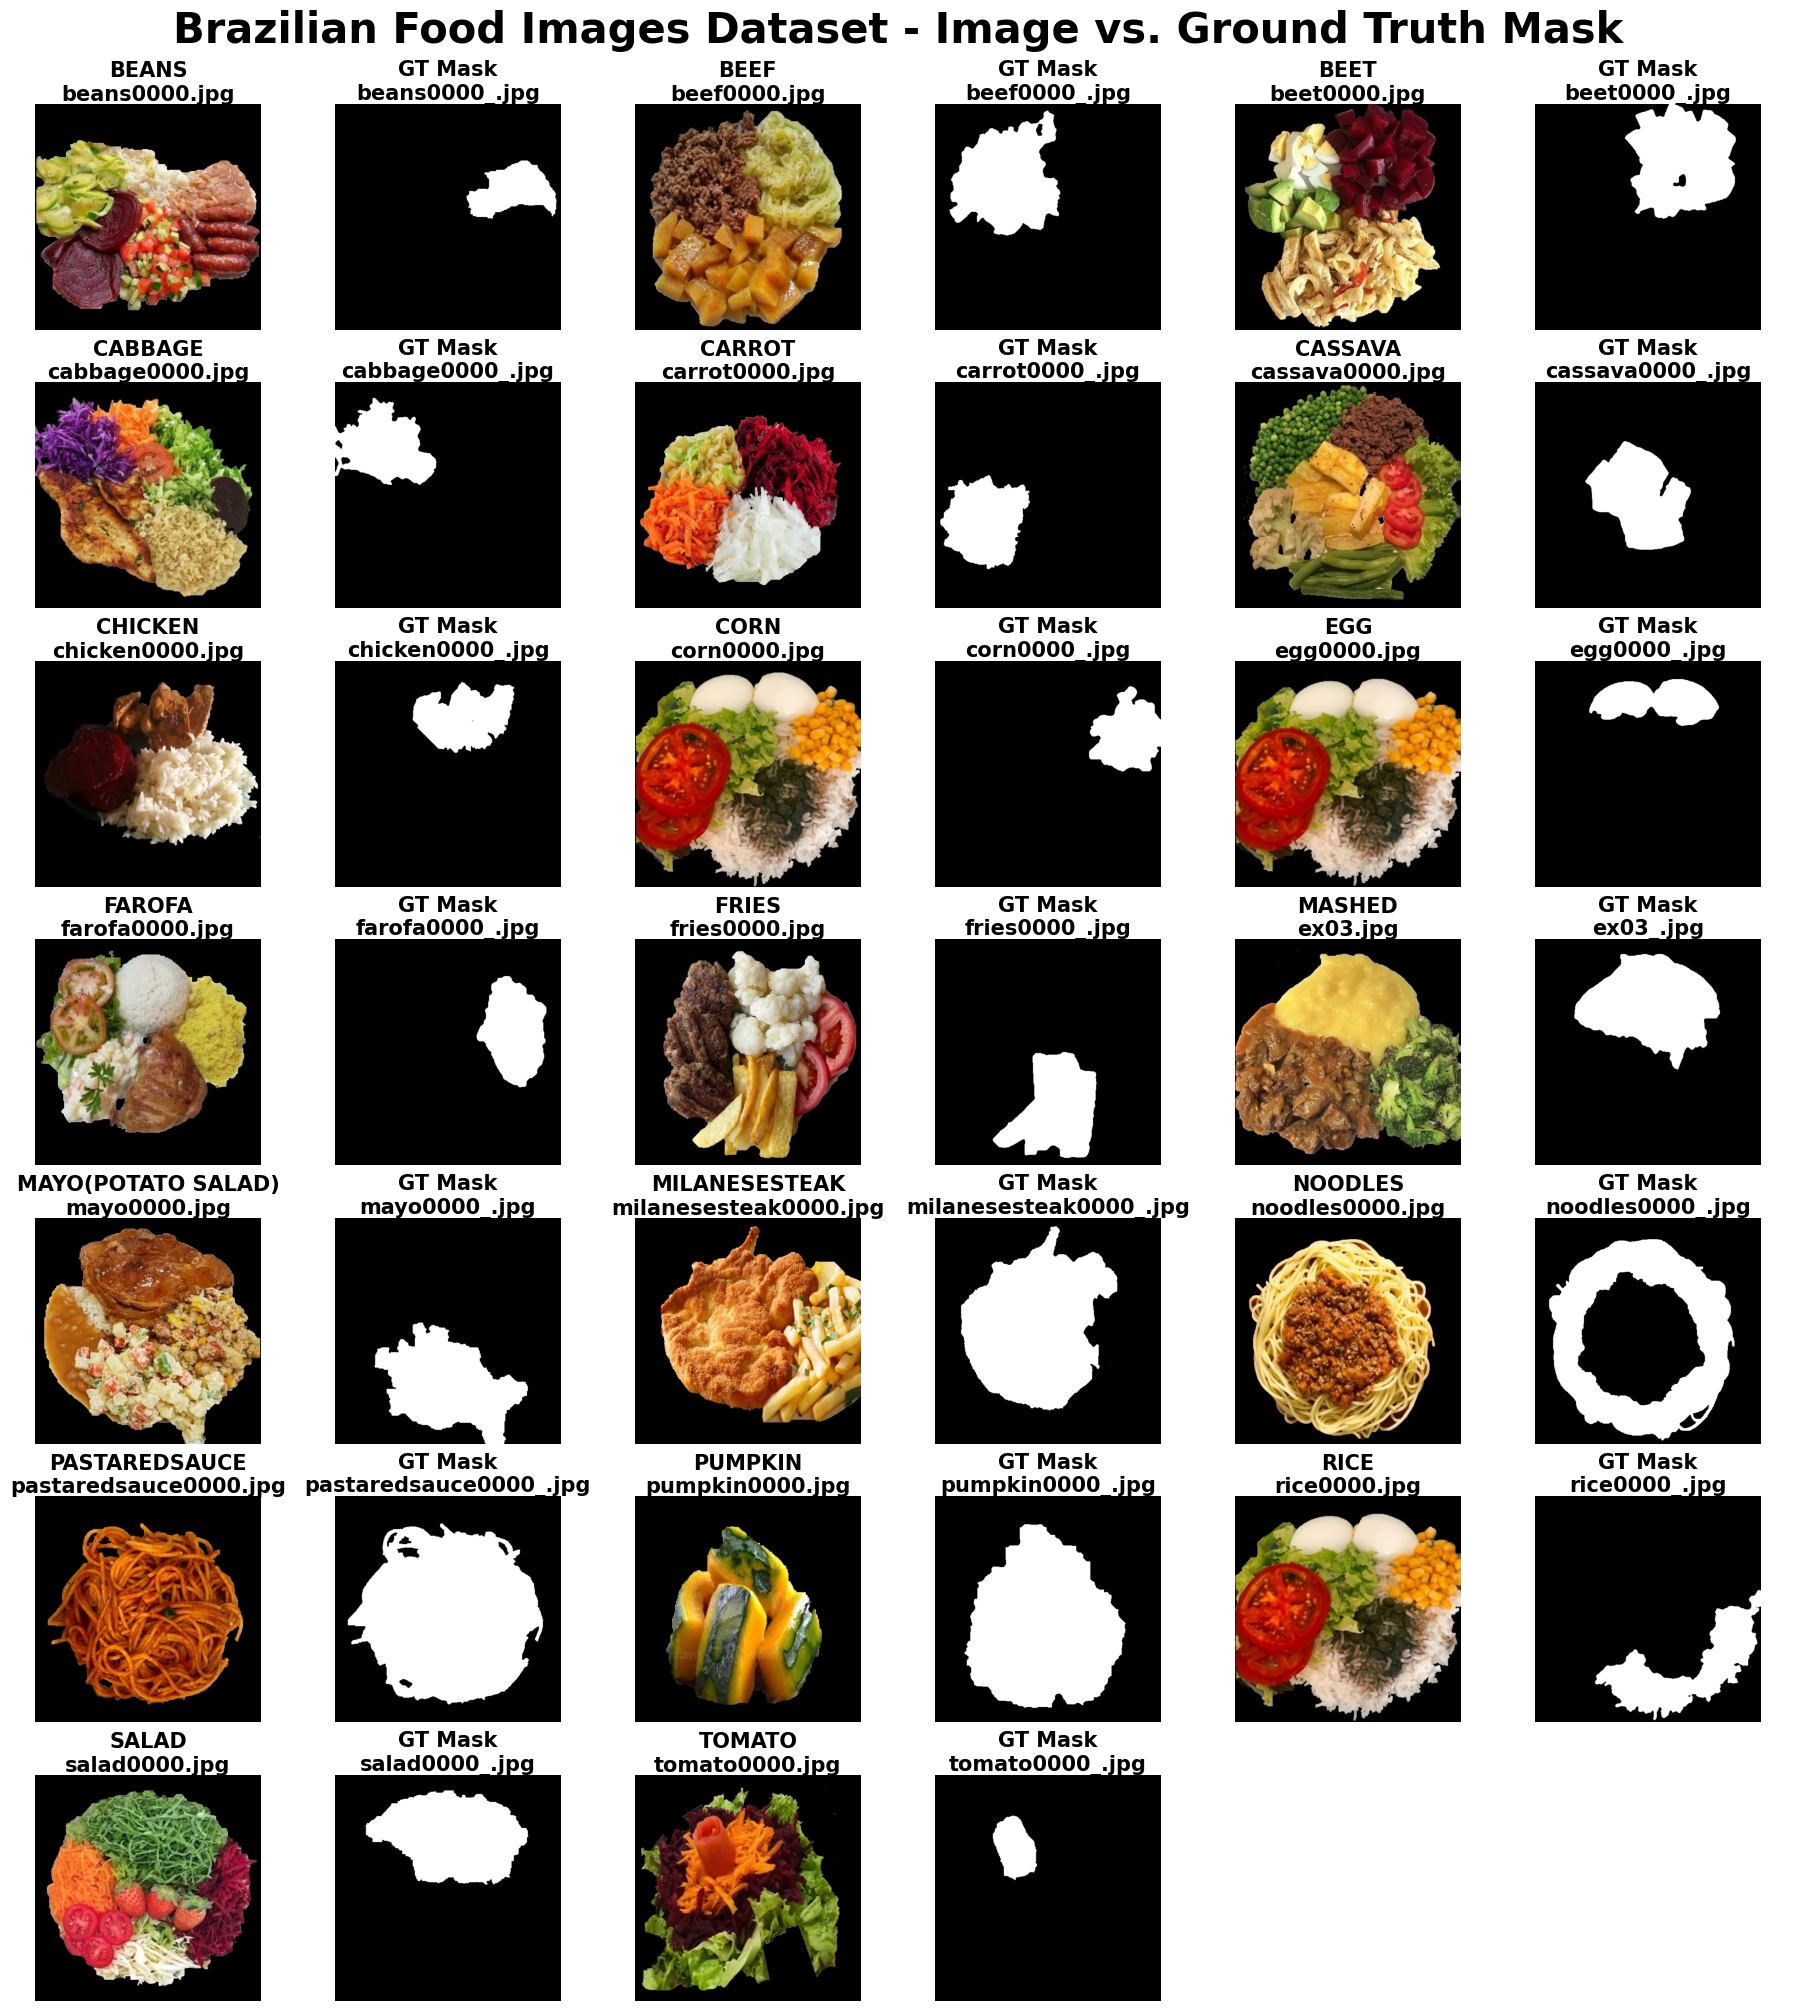

In [1]:
import os
import math
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive

# We start mounting Google Drive to access stored dataset files:
drive.mount('/content/drive')
# Then, the path definition for the dataset directory in Google Drive:
data_dir = "/content/drive/MyDrive/Colab Notebooks/Brazilian food images"

# Inside the dataset directory, we have two folders: training_set and test_set.
# training_set contains 20 classes of brazilian food images, with original images and the ground-truth masks.
# Besides, the test_set contains 160 meal images.

# Let's pick the training_set folder to show some of those images:
training_folder = os.path.join(data_dir, "training_set")

# Some of the folders inside it do not have images, so we can ignore them:
ignored_folders = {".git", "dataset"}

# Retrieving and filtering food category folder names directly, we have:
raw_categories = sorted([d for d in os.listdir(training_folder) if os.path.isdir(os.path.join(training_folder, d))])
categories = [c for c in raw_categories if c not in ignored_folders]

valid_samples = []

for category in categories:
    category_dir = os.path.join(training_folder, category)
    # The start is considering only the original images (not the mask ones, which have the suffix _.jpg, unlike the originals):
    image_files = sorted([f for f in os.listdir(category_dir) if not f.endswith("_.jpg")])
    sample_img = image_files[0]
    # The masks:
    sample_mask = sample_img.replace(".jpg", "_.jpg")
    # The paths for both of them:
    img_path = os.path.join(category_dir, sample_img)
    mask_path = os.path.join(category_dir, sample_mask)

    valid_samples.append({
        "category": category,
        "img_name": sample_img,
        "mask_name": sample_mask,
        "img_path": img_path,
        "mask_path": mask_path
    })

# Finally, proceed to showing the images:

pairs_per_row = 3
cols_total = pairs_per_row * 2  # [Img1, Mask1, Img2, Mask2, Img3, Mask3
num_rows = math.ceil(len(valid_samples) / pairs_per_row)

fig, axes = plt.subplots(num_rows, cols_total, figsize=(18, 20), constrained_layout=True)

axes_flat = axes.flatten()

for i, item in enumerate(valid_samples):
    ax_img = axes_flat[i * 2]
    ax_mask = axes_flat[i * 2 + 1]

    img = Image.open(item["img_path"])
    mask = Image.open(item["mask_path"])

    # Plot original image:
    ax_img.imshow(img)
    ax_img.set_title(f"{item['category'].upper()}\n{item['img_name']}", fontsize=15, fontweight='bold', pad=2)
    ax_img.axis("off")

    # Plot ground truth mask:
    ax_mask.imshow(mask, cmap="gray")
    ax_mask.set_title(f"GT Mask\n{item['mask_name']}", fontsize=15, fontweight='bold', pad=2)
    ax_mask.axis("off")

# Hiding spare/unused subplots:
for j in range(len(valid_samples) * 2, len(axes_flat)):
    axes_flat[j].axis("off")

# Setting global title for the layout:
plt.suptitle("Brazilian Food Images Dataset - Image vs. Ground Truth Mask", fontsize=30, fontweight='bold')

plt.show()

# ***Step 2 - Object segmentation & Mask generation (SAM)***

## ***Step 2.1 — Environment setup & Model checkpoint retrieval***

*To establish our segmentation baseline, we install the official Segment Anything Model (SAM 1) repository provided by Meta AI alongside its core Computer Vision dependencies*:
- *torchvision*
- *pycocotools*
- *opencv-python*

*We then retrieve the pre-trained weights for the Vision Transformer Huge (ViT-H) backbone to ensure zero-shot segmentation fidelity on different food items*.

In [2]:
!rm sam_vit_h_4b8939.pth
# Segment Anything Model (SAM 1) directly from Meta's GitHub repository:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
# PyTorch dependencies and computer vision packages:
!pip install -q torchvision pycocotools opencv-python
# Default ViT-Huge checkpoint:
!wget --show-progress -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

rm: cannot remove 'sam_vit_h_4b8939.pth': No such file or directory
  Preparing metadata (setup.py) ... done
sam_vit_h_4b8939.pt 100%[===================>]   2.39G   111MB/s    in 15s     


In [3]:
import torch
import segment_anything
from segment_anything import sam_model_registry, SamPredictor

# Hardware acceleration (GPU if available, CPU as fallback):
device = "cuda" if torch.cuda.is_available() else "cpu"

# Checkpoint path and its corresponding ViT architecture type:
sam_checkpoint = "sam_vit_h_4b8939.pth"
model_type = "vit_h"

# Instancing the model from the registry using the selected architecture:
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)

# Transfering the model weights to the GPU/CPU memory device:
sam.to(device=device)

# Initializing the predictor interface for image embeddings:
predictor = SamPredictor(sam)

print(f"SAM ({model_type}) loaded successfully on {device}.")

SAM (vit_h) loaded successfully on cuda.


## ***Step 2.2 - Single-sample inference & Qualitative overlay analysis***

*To validate the model's spatial accuracy on individual items, we extract a bounding box from a sample's Ground Truth mask to serve as SAM's spatial prompt. SAM processes the image embeddings and outputs a predicted binary mask, alongside its internal IoU Confidence Score*.

*We compute the actual Intersection over Union (IoU) metric against the Ground Truth and generate a 4-panel visual benchmarking plot*:
- ***Original Image & Bounding Box Prompt***: *Highlights the spatial constraint passed to SAM*.
- ***Ground Truth Mask***: *The target segmentation binary mask*.
- ***SAM Predicted Mask***: *The model's prediction*.
- ***Segmentation Difference (RGB Error Map)***: *An overlap visualization highlighting true positives (Green), false positives / over-segmentation (Red), and false negatives / under-segmentation (Blue)*.

Sample: BEANS (beans0000.jpg)
SAM confidence score: 0.8948
Segmentation accuracy (IoU vs GT): 87.08%


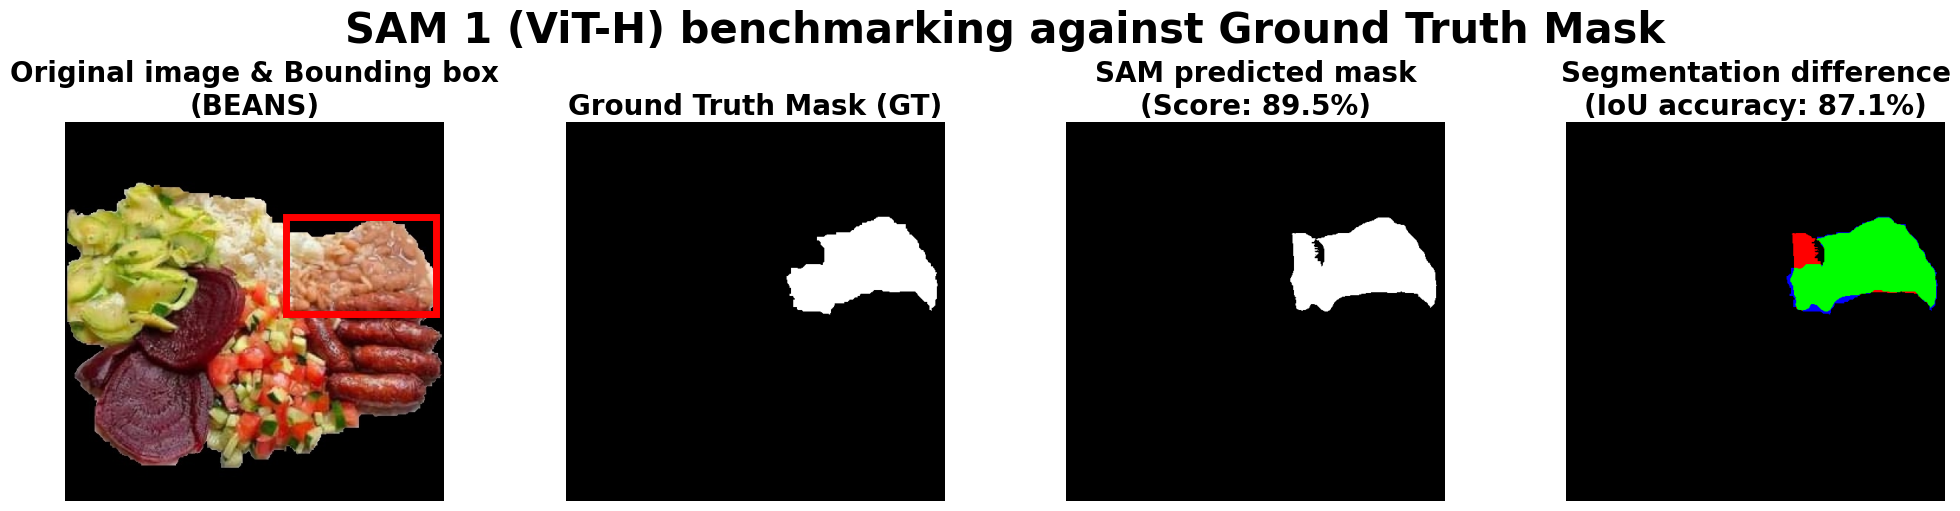

In [4]:
import cv2
import numpy as np

# Selecting the first sample from our validated dataset (in this case, beans):
sample = valid_samples[0]

# Now we can load the original image and GT mask.

# The original image:
image_bgr = cv2.imread(sample["img_path"])
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# The mask in grayscale:
mask_gt = cv2.imread(sample["mask_path"], cv2.IMREAD_GRAYSCALE)
# Binarizing GT mask (0 or 1):
mask_gt_binary = (mask_gt > 128).astype(np.uint8)

# After this, it is possible to extract Bounding Box from GT Mask to use as SAM prompt:
y_indices, x_indices = np.where(mask_gt_binary > 0)
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()
input_box = np.array([x_min, y_min, x_max, y_max])

# Furthermore, we can pass the image embedding to SAM Predictor:
predictor.set_image(image_rgb)

# SAM inference, guided by the bounding box prompt:
masks_pred, scores, logits = predictor.predict(
    box=input_box[None, :],
    multimask_output=False
)
sam_mask = masks_pred[0].astype(np.uint8)

# Now, we have the SAM predicted mask in hands. So, let's compare it with our GT Mask.
# For this task, we can use some well-established metrics like IoU (Intersection over Union).
# Let's calculate Intersection over Union (IoU) Benchmarking:

intersection = np.logical_and(mask_gt_binary, sam_mask).sum()
union = np.logical_or(mask_gt_binary, sam_mask).sum()
iou_score = intersection / union

print(f"Sample: {sample['category'].upper()} ({sample['img_name']})")
print(f"SAM confidence score: {scores[0]:.4f}")
print(f"Segmentation accuracy (IoU vs GT): {iou_score * 100:.2f}%")

# Visual comparison plot:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)

# Original image with prompt bounding box:
axes[0].imshow(image_rgb)
rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                     fill=False, edgecolor='red', lw=5)
axes[0].add_patch(rect)
axes[0].set_title(f"Original image & Bounding box\n({sample['category'].upper()})", fontsize=20, fontweight='bold')
axes[0].axis('off')

# GT Mask:
axes[1].imshow(mask_gt_binary, cmap='gray')
axes[1].set_title("Ground Truth Mask (GT)", fontsize=20, fontweight='bold')
axes[1].axis('off')

# SAM Predicted Mask:
axes[2].imshow(sam_mask, cmap='gray')
axes[2].set_title(f"SAM predicted mask\n(Score: {scores[0]*100:.1f}%)", fontsize=20, fontweight='bold')
axes[2].axis('off')

# Mask difference (Overlay):

overlap_vis = np.zeros((*mask_gt_binary.shape, 3), dtype=np.uint8)

# Green = Correct match (Intersection)
# Red = False positive (predicted by SAM, but doesn't exist in GT)
# Blue = False Negative (exists in GT, but SAM doesn't predict):


# Correct match (Green):
correct_match = np.logical_and(mask_gt_binary == 1, sam_mask == 1) # Where SAM and GT agree
overlap_vis[correct_match, 1] = 255 # Green channel

# False positive (Red):
sam_extra = np.logical_and(mask_gt_binary == 0, sam_mask == 1) # Where SAM predicts but doesn't exist in GT
overlap_vis[sam_extra, 0] = 255 # Red channel

# False negative (Blue):
gt_extra = np.logical_and(mask_gt_binary == 1, sam_mask == 0) # Where SAM doesn't predict but exists in GT
overlap_vis[gt_extra, 2] = 255 # Blue channel

# Overlap visualization:
axes[3].imshow(overlap_vis)
axes[3].set_title(f"Segmentation difference\n(IoU accuracy: {iou_score*100:.1f}%)", fontsize=20, fontweight='bold')
axes[3].axis('off')

plt.suptitle("SAM 1 (ViT-H) benchmarking against Ground Truth Mask", fontsize=30, fontweight='bold')
plt.show()

## ***Step 2.3 — Full dataset batch benchmarking & Class-wise mIoU evaluation***

*To rigorously measure SAM's generalization across all 20 food classes, we execute a batch inference loop over the entire dataset*.

*For every pair, SAM extracts a bounding box prompt from the ground truth, generates the predicted segmentation, and calculates*:
- ***Per-class Mean IoU ($\text{mIoU}$)***: *Quantitative alignment accuracy against ground-truth annotations across food types*.
- ***Global Dataset $\text{mIoU}$***: *The baseline performance metric across all sample pairs*.
- ***Confidence Score Calibration***: *Correlation between SAM's internal confidence head and the empirical IoU*.

In [5]:
import pandas as pd
import seaborn as sns

all_samples = []

for category in categories:
    category_dir = os.path.join(training_folder, category)
    image_files = sorted([f for f in os.listdir(category_dir) if not f.endswith("_.jpg")])

    for img_name in image_files:
        mask_name = img_name.replace(".jpg", "_.jpg")
        img_path = os.path.join(category_dir, img_name)
        mask_path = os.path.join(category_dir, mask_name)

        all_samples.append({
                "category": category,
                "img_name": img_name,
                "mask_name": mask_name,
                "img_path": img_path,
                "mask_path": mask_path
            })

print(f"Total mapped image-mask pairs in the complete dataset: {len(all_samples)}")

Total mapped image-mask pairs in the complete dataset: 915


In [6]:
results = []

for sample in all_samples:

    image_bgr = cv2.imread(sample["img_path"])
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    predictor.set_image(image_rgb)

    mask_gt = cv2.imread(sample["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask_gt_binary = (mask_gt > 128).astype(np.uint8)

    y_indices, x_indices = np.where(mask_gt_binary > 0)
    input_box = np.array([x_indices.min(), y_indices.min(), x_indices.max(), y_indices.max()])

    masks_pred, scores, _ = predictor.predict(
        box=input_box[None, :],
        multimask_output=False
    )

    sam_mask = masks_pred[0].astype(np.uint8)

    intersection = np.logical_and(mask_gt_binary, sam_mask).sum()
    union = np.logical_or(mask_gt_binary, sam_mask).sum()
    iou_score = intersection / union

    results.append({
        "Category": sample["category"],
        "Image": sample["img_name"],
        "SAM_Score": scores[0],
        "IoU": iou_score
    })


In [7]:
df_results = pd.DataFrame(results)

df_mIoU = df_results.groupby("Category").agg(
    Samples=("IoU", "count"),
    mIoU=("IoU", "mean"),
    Mean_SAM_score=("SAM_Score", "mean")
).reset_index()

df_mIoU["mIoU (%)"] = (df_mIoU["mIoU"] * 100).round(2)
df_mIoU["Mean_SAM_score"] = (df_mIoU["Mean_SAM_score"] * 100).round(2)

global_mIoU = df_results["IoU"].mean() * 100

print(f"Total processed samples: {len(df_results)}")
print(f"Global dataset mean IoU (mIoU): {global_mIoU:.2f}%")

display(df_mIoU[["Category", "Samples", "mIoU (%)", "Mean_SAM_score"]])

Total processed samples: 915
Global dataset mean IoU (mIoU): 91.08%


,Category,Samples,mIoU (%),Mean_SAM_score
0,beans,79,93.85,96.930000
1,beef,85,92.01,96.230003
2,beet,33,90.78,95.339996
3,cabbage,18,88.60,95.989998
4,carrot,70,87.55,94.389999
5,cassava,16,95.81,93.540001
6,chicken,58,92.96,96.230003
7,corn,18,90.41,96.339996
8,egg,27,84.58,90.570000
9,farofa,34,90.87,95.769997


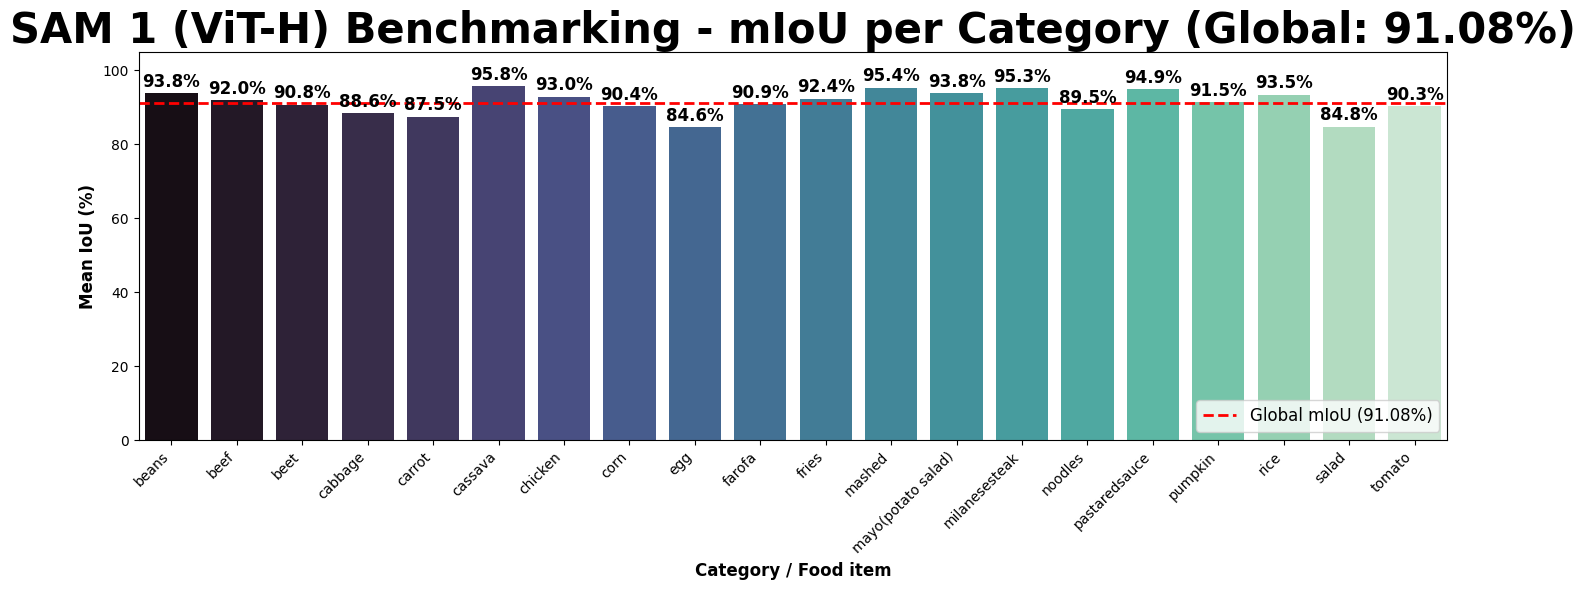

In [8]:
plt.figure(figsize=(14, 6))

# Now, we can plot the bar chart:
ax = sns.barplot(
    data=df_mIoU,
    x="Category",
    y="mIoU (%)",
    hue="Category",
    palette="mako",
    legend=False
)

plt.title(f"SAM 1 (ViT-H) Benchmarking - mIoU per Category (Global: {global_mIoU:.2f}%)", fontweight="bold", fontsize=30)
plt.xlabel("Category / Food item", fontweight="bold", fontsize=12)
plt.ylabel("Mean IoU (%)", fontweight="bold", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 105)

# Horizontal dashed line for global average:
plt.axhline(global_mIoU, color="red", linestyle="--", linewidth=2, label=f"Global mIoU ({global_mIoU:.2f}%)")

# Annotating percentage values above each bar:
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1f}%", (p.get_x() + p.get_width() / 2., height), ha='center', va='center', xytext=(0, 8),
                textcoords='offset points', fontweight='bold', fontsize=12)

plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()

# ***Step 3.1 - Synthetic omission via Pixel Zeroing (Blackout)***



In [19]:
def generate_blackout_food_sample(sample_dict, predictor, dilation_kernel=9):
    """
    Here, we generate a synthetic image sample by removing the target ingredient via SAM
    and applying absolute Pixel Zeroing (blackout) to the segmented region.

    Parameters:
        sample_dict (dict): Dictionary containing paths for the original image and GT mask.
        predictor (SamPredictor): Initialized SAM (ViT-H) model instance.
        dilation_kernel (int): Morphological kernel size to expand mask boundaries
                               and eliminate edge/shadow artifacts.
    """

    # Again we load the original image and GT mask:
    img_bgr = cv2.imread(sample_dict["img_path"])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mask_gt = cv2.imread(sample_dict["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask_gt_binary = (mask_gt > 128).astype(np.uint8)

    # Moreover, we can extract the bounding box and SAM predicted mask:
    y_idx, x_idx = np.where(mask_gt_binary > 0)
    input_box = np.array([x_idx.min(), y_idx.min(), x_idx.max(), y_idx.max()])

    predictor.set_image(img_rgb)
    masks_pred, _, _ = predictor.predict(box=input_box[None, :], multimask_output=False)
    sam_mask = masks_pred[0].astype(np.uint8)

    # Post-processing mask using morphological dilation to cover outlines and shadows:
    if dilation_kernel > 0:
        kernel = np.ones((dilation_kernel, dilation_kernel), np.uint8)
        sam_mask_dilated = cv2.dilate(sam_mask, kernel, iterations=1)
    else:
        sam_mask_dilated = sam_mask

    # Pixel Zeroing (Blackout):
    synthetic_image = img_rgb.copy()
    synthetic_image[sam_mask_dilated == 1] = [0, 0, 0]

    return img_rgb, sam_mask_dilated, synthetic_image

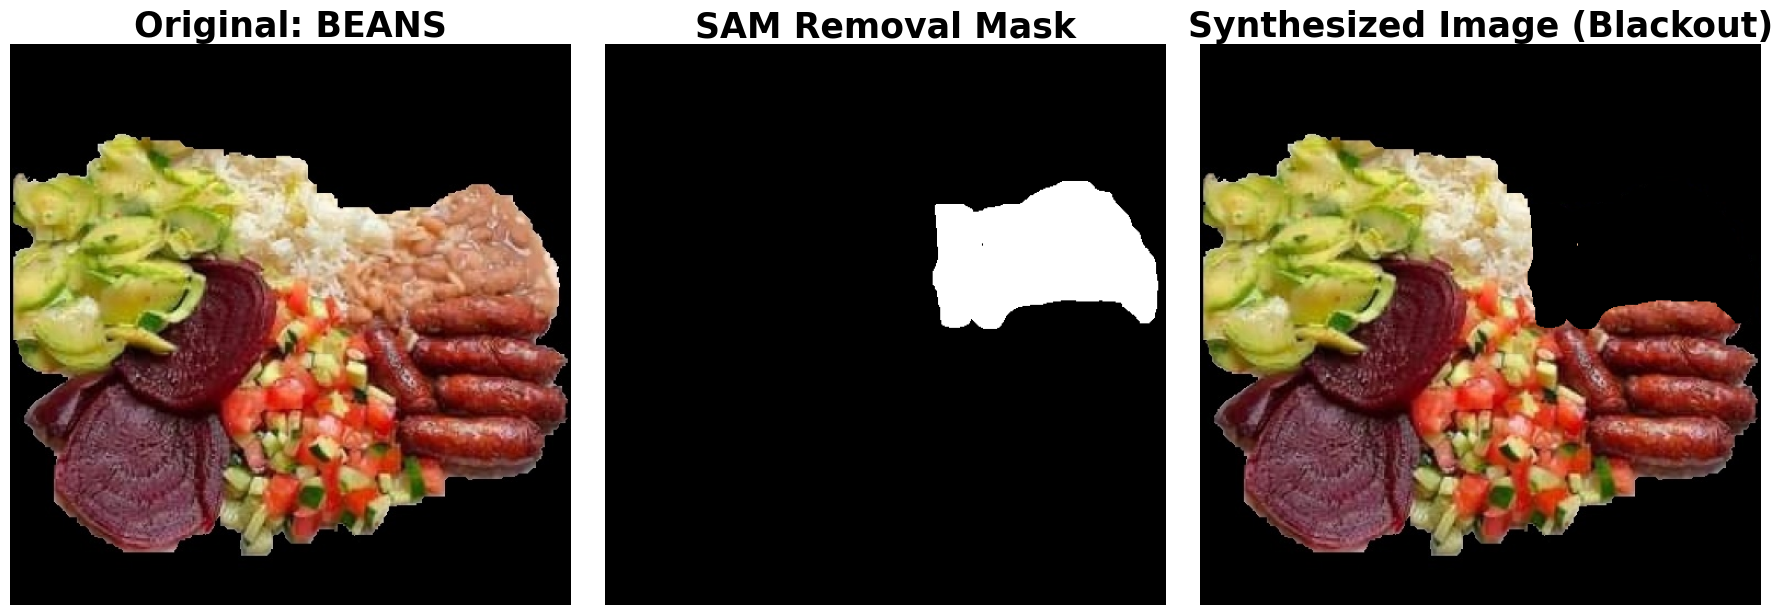

In [20]:
# Now, it is possible to test this last function with the beans image:
sample = valid_samples[0]

original_img, mask_used, synthetic_result = generate_blackout_food_sample(
    sample_dict=sample,
    predictor=predictor,
    dilation_kernel=9
)

# Visualizing the original, SAM predicted mask and synthethized images (with the beans erased):
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_img)
axes[0].set_title(f"Original: {sample['category'].upper()}", fontweight="bold", fontsize=25)
axes[0].axis("off")

axes[1].imshow(mask_used, cmap="gray")
axes[1].set_title("SAM Removal Mask", fontweight="bold", fontsize=25)
axes[1].axis("off")

axes[2].imshow(synthetic_result)
axes[2].set_title("Synthesized Image (Blackout)", fontweight="bold", fontsize=25)
axes[2].axis("off")

plt.tight_layout()
plt.show()

# ***Step 3.2 - Synthetic Omission via Inpainting (Stable Diffusion)***

In [21]:
from diffusers import StableDiffusionInpaintPipeline

# Dependencies for Inpainting:
!pip install -q diffusers transformers accelerate

# Loading inpainting model into the GPU accelerator:
model_id = "runwayml/stable-diffusion-inpainting"
inpaint_pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to("cuda")

inpaint_pipe.safety_checker = None

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

In [23]:
def generate_synthetic_food_sample(
    sample_dict,
    predictor,
    inpaint_pipe,
    prompt="a clean empty white plate surface, seamless background",
    dilation_kernel=9
):
    """
    Here, we generate a synthetic image sample by removing the target ingredient via SAM
    and applying Inpainting to the segmented region.

    Parameters:
        sample_dict (dict): Dictonary containing paths for the original image and GT mask.
        predictor (SamPredictor): Initialized SAM object.
        inpaint_pipe (Pipeline): Inpainting model pipeline.
        prompt (str)
        dilation_kernel (int): Smooth expansion of the mask to avoid residual edges.
    """
    # Loading original image and GT mask:
    img_bgr = cv2.imread(sample_dict["img_path"])
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    mask_gt = cv2.imread(sample_dict["mask_path"], cv2.IMREAD_GRAYSCALE)
    mask_gt_binary = (mask_gt > 128).astype(np.uint8)

    # Extracting bounding boxes and generating masks with SAM:
    y_idx, x_idx = np.where(mask_gt_binary > 0)
    input_box = np.array([x_idx.min(), y_idx.min(), x_idx.max(), y_idx.max()])

    predictor.set_image(img_rgb)
    masks_pred, _, _ = predictor.predict(box=input_box[None, :], multimask_output=False)
    sam_mask = masks_pred[0].astype(np.uint8)

    # We can do the dilation process:
    if dilation_kernel > 0:
        kernel = np.ones((dilation_kernel, dilation_kernel), np.uint8)
        sam_mask_dilated = cv2.dilate(sam_mask, kernel, iterations=1)
    else:
        sam_mask_dilated = sam_mask

    # Converting image to PIL (HuggingFace Diffusers standard)
    init_image = Image.fromarray(img_rgb).resize((512, 512))
    mask_image = Image.fromarray(sam_mask_dilated * 255).resize((512, 512))

    # Inpainting inference:
    synthetic_image = inpaint_pipe(
        prompt=prompt,
        image=init_image,
        mask_image=mask_image,
        guidance_scale=7.5,
        num_inference_steps=30
    ).images[0]

    synthetic_image_resized = synthetic_image.resize((img_rgb.shape[1], img_rgb.shape[0]))

    return img_rgb, sam_mask_dilated, synthetic_image_resized

  0%|          | 0/30 [00:00<?, ?it/s]

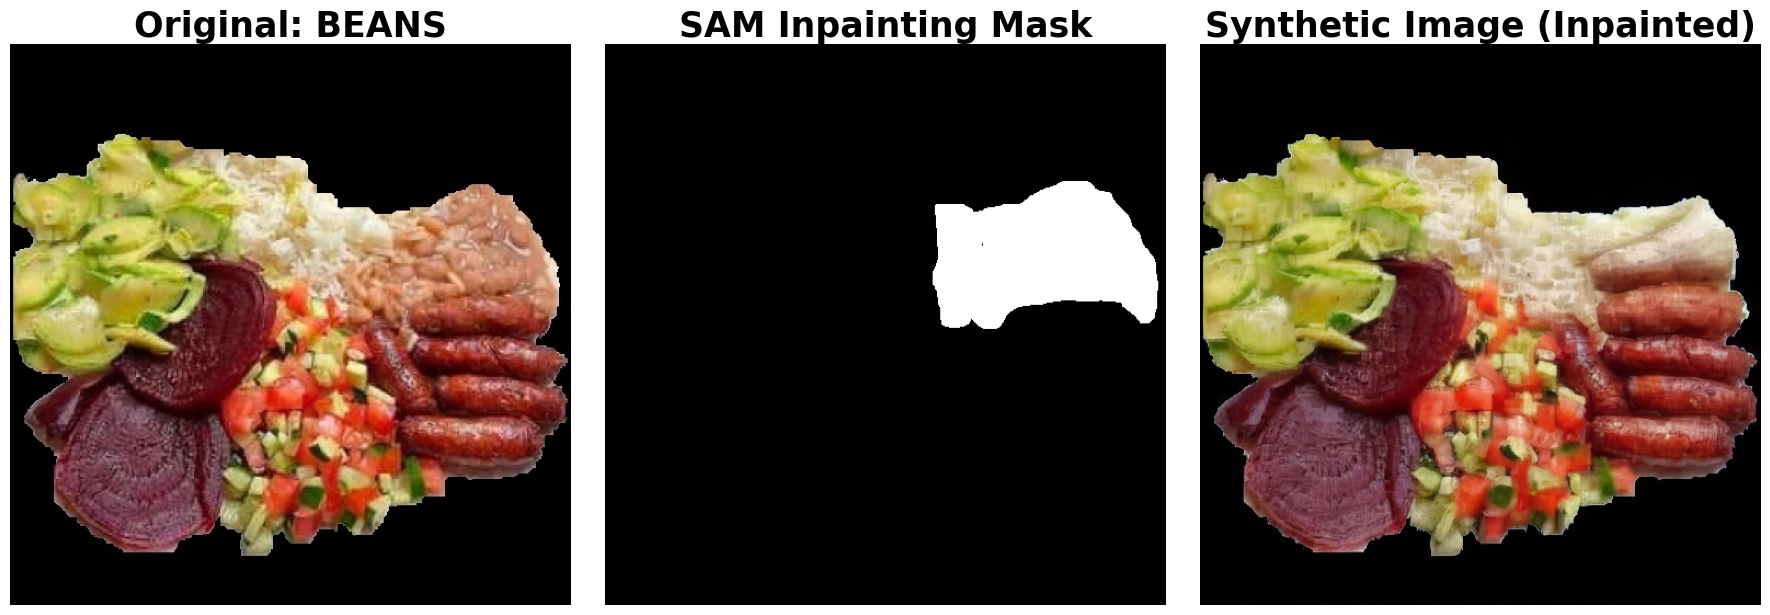

In [24]:
# Now, it is possible to test this last function with the beans image:
sample = valid_samples[0]

original_img, mask_used, synthetic_result = generate_synthetic_food_sample(
    sample_dict=sample,
    predictor=predictor,
    inpaint_pipe=inpaint_pipe,
    prompt="clean ceramic plate texture"
)

# Visualizing the original, SAM predicted mask and synthethized images (with the beans erased):
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_img)
axes[0].set_title(f"Original: {sample['category'].upper()}", fontweight="bold", fontsize="25")
axes[0].axis("off")

axes[1].imshow(mask_used, cmap="gray")
axes[1].set_title("SAM Inpainting Mask", fontweight="bold", fontsize="25")
axes[1].axis("off")

axes[2].imshow(synthetic_result)
axes[2].set_title("Synthetic Image (Inpainted)", fontweight="bold", fontsize="25")
axes[2].axis("off")

plt.tight_layout()
plt.show()

*But note that Inpainting method conflicts with the fact that this dataset has images with complete black background, generating strange patterns on the Inpainted image (mixing the foods that are present on the meal). Therefore, the use of the image obtained in the Step 3.1 looks more suitable to proceed to Qwen-VL Inference*.  

# ***Step 4 - Semantic Cross-Verification (Qwen-VL Inference)***

In [25]:
sample = valid_samples[0]

img_rgb, mask, synthetic_image = generate_blackout_food_sample(sample, predictor)
output_image_path = "/content/synthetic_beans_blackout.png"

cv2.imwrite(output_image_path, cv2.cvtColor(synthetic_image, cv2.COLOR_RGB2BGR))

print(f"The synthethic image is ready in: {output_image_path}")

The synthethic image is ready in: /content/synthetic_beans_blackout.png


In [27]:
import argparse
import json
from pathlib import Path
from dotenv import load_dotenv
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration

# We start setting up the arguments on terminal:

parser = argparse.ArgumentParser(description="Step 4: Qwen-VL Order Cross-Verification")
parser.add_argument(
    "--images",
    default=r"/content/synthetic_beans_blackout.png",
    help="Synthetic image (blackout) path generated in Step 3.",
)
parser.add_argument(
    "--receipt",
    nargs="+",
    default=["white rice", "beans", "sausage", "vinaigrette salad", "beetroot"],
    help="Itens expected on the meal (receipt).",
)
parser.add_argument(
    "--output",
    default="audit_results.json",
    help="JSON file to store the inference results",
)
parser.add_argument(
    "--max-new-tokens",
    type=int,
    default=256,
)
args, _ = parser.parse_known_args()

# Loading HuggingFace token:
load_dotenv()
hf_token = os.getenv("HF_TOKEN") or os.getenv("HUGGING_FACE_HUB_TOKEN")

# Initializing Qwen-VL model instance and processor:
print("Loading Qwen3-VL-8B-Instruct")
model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-8B-Instruct",
    dtype="auto",
    device_map="auto",
    token=hf_token,
)

processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen3-VL-8B-Instruct",
    token=hf_token,
)

Loading Qwen3-VL-8B-Instruct


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

In [28]:
def build_verification_prompt(receipt_items):
    """
    We can create our prompt with the following:
    """
    formatted_receipt = ", ".join(receipt_items)

    prompt = f"""You are an AI order verification auditor for a food delivery platform.
Analyze the provided image of a meal plate and cross-reference it against the expected receipt items below.

Expected Receipt Items: [{formatted_receipt}]

Tasks:
1. Identify all food items physically present on the plate in the image.
2. Cross-reference the detected items with the expected receipt.
3. Explicitly list any item from the receipt that is MISSING from the plate.

Output MUST be a strictly formatted JSON object with no preamble or markdown syntax outside the JSON.
Required JSON format:
{{
  "expected_items": [{formatted_receipt}],
  "detected_items": ["item1", "item2"],
  "missing_items": ["item1"],
  "is_order_complete": false,
  "confidence_reasoning": "Short explanation of missing or verified items."
}}
"""
    return prompt

In [29]:
IMAGE_EXTENSIONS = {".bmp", ".jpeg", ".jpg", ".png", ".tif", ".tiff", ".webp"}

image_source = Path(args.images)
if args.images.startswith(("http://", "https://")):
    image_paths = [args.images]
elif image_source.is_dir():
    image_paths = [
        str(path)
        for path in sorted(image_source.iterdir())
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]
elif image_source.is_file():
    image_paths = [str(image_source)]
else:
    raise FileNotFoundError(f"Caminho da imagem não encontrado: {args.images}")

prompt_text = build_verification_prompt(args.receipt)
audit_results = []

# Inference loop:
print(f"Inicializing inference for {len(image_paths)} image(s)")

for image_path in image_paths:

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": str(image_path),
                },
                {
                    "type": "text",
                    "text": prompt_text
                },
            ],
        }
    ]

    # Input tensors:
    inputs = processor.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_dict=True,
        return_tensors="pt"
    )
    inputs = inputs.to(model.device)

    # Deterministic inference:
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=args.max_new_tokens,
        do_sample=False,
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    print(f"\nResults for: {image_path}")
    print(output_text)

    audit_results.append({
        "image_path": image_path,
        "vlm_raw_response": output_text
    })

Inicializing inference for 1 image(s)

Results for: /content/synthetic_beans_blackout.png
{
  "expected_items": ["white rice", "beans", "sausage", "vinaigrette salad", "beetroot"],
  "detected_items": ["white rice", "sausage", "beetroot", "vinaigrette salad"],
  "missing_items": ["beans"],
  "is_order_complete": false,
  "confidence_reasoning": "Beans are not visible on the plate; all other expected items are present."
}


In [31]:
# We can organize better our response in the JSON before saving:

for item in audit_results:
    try:
        item["parsed_audit"] = json.loads(item["vlm_raw_response"])
    except json.JSONDecodeError:
        raw = item["vlm_raw_response"]
        clean_json_str = raw.replace("```json", "").replace("```", "").strip()
        try:
            item["parsed_audit"] = json.loads(clean_json_str)
        except Exception:
            item["parsed_audit"] = None

with open(args.output, "w", encoding="utf-8") as f:
    json.dump(audit_results, f, ensure_ascii=False, indent=2)

print(f"\nThe process is concluded. Results are available in: {args.output}")


The process is concluded. Results are available in: audit_results.json
